In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from util import *
import os
import torch
#import tensorflow as tf
from cnn.model import ConvBlock
#import cnn_tf.model as tf_model
import numpy as np

In [ ]:
# disable all tensorflow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [ ]:
# Load config file
file_path = os.path.join(os.getcwd(), 'config_files', 'config2.txt')
config_file = load_yaml(file_path)

## Test ConvBlock

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
conv_block = ConvBlock(kernel = kernel,
                       in_channels = x_torch.shape[3],
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [ ]:
tf_conv_block = tf_model.ConvBlock(kernel = kernel,
                                   strides = stride,
                                   filters = filters,
                                   mu=mu, 
                                   epsilon=epsilon)

In [ ]:
np.isclose(x_torch, x_tf).all()

In [ ]:
y_torch = conv_block(x_torch).detach().numpy()
y_tf = tf_conv_block(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Max Pooling

In [ ]:
from cnn.model import MaxPooling

In [ ]:
# create a a image tensor to test the max pooling layer
max_pool = MaxPooling(kernel=3, strides=1)
tf_max_pool = tf_model.MaxPooling(kernel=3, strides=1)

y_tf = tf_max_pool(x_tf, name="max_pool")
y_torch = max_pool(x_torch).detach().numpy()

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Avg Pooling

In [ ]:
from cnn.model import AvgPooling

avg_pool = AvgPooling(kernel=3, strides=1)
y_torch = avg_pool(x_torch).detach().numpy()

tf_avg_pool = tf_model.AvgPooling(kernel=3, strides=1)
y_tf = tf_avg_pool(x_tf, name='avg_pool')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Fully Connected Layer

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(32, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import FullyConnected

# flatten the tensor
num_features = x_torch.shape[1] * x_torch.shape[2] * x_torch.shape[3]
units = 20

fc_torch = FullyConnected(input_features=num_features, units=units)
fc_tf = tf_model.FullyConnected(units=units)

x_tor = torch.reshape(x_torch, [-1, num_features])
x_tfl = tf.reshape(x_tf, [-1, num_features])

y_torch = fc_torch(x_tor).detach().numpy()
y_tf = fc_tf(x_tfl, name='fc')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Pad Feature

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 8).astype(np.float32)
X1 = np.random.rand(1, 6, 6, 6).astype(np.float32)

x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

x_torch1 = torch.from_numpy(X1)
x_tf1 = tf.convert_to_tensor(X1, dtype=tf.float32)


In [ ]:
from cnn.model import pad_features

torch_tensors = [x_torch, x_torch1]
tf_tensors = [x_tf, x_tf1]


torch_padded = pad_features(tensors=torch_tensors)
tf_padded = tf_model.pad_features(tensors=tf_tensors)

torch_padded[0].shape, torch_padded[1].shape, tf_padded[0].shape, tf_padded[1].shape

## Test ResidualV1

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 3, 64, 64).astype(np.float32)
x_torch = torch.from_numpy(X)
#x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import ResidualV1CBAM

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1 = ResidualV1CBAM(kernel = kernel,
                    in_channel = x_torch.shape[1],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [ ]:
Res_v1

In [ ]:
# tf_Res = tf_model.ResidualV1(kernel = kernel,
#                        strides = stride, 
#                        filters = filters, 
#                        mu=mu,
#                        epsilon=epsilon)

In [ ]:
np.isclose(x_torch, x_tf).all()

In [ ]:
y_torch = Res_v1(x_torch).detach().numpy()
#y_tf = tf_Res(x_tf, name="conv_block")

#print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test ResidualV1Pr

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import ResidualV1Pr

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1Pr = ResidualV1Pr(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [ ]:
Res_v1Pr

In [ ]:
tf_ResPR = tf_model.ResidualV1Pr(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [ ]:
y_torch = Res_v1Pr(x_torch).detach().numpy()
y_tf = tf_ResPR(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

## Test Depthwise Separable Convolution Block

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
import torch.nn as nn
import torch
from cnn.model import DepthConvBlock

In [ ]:
# Example usage
in_channels = 3
filters = 64
kernel_size = 3

In [ ]:
depthwise_conv = DepthConvBlock(kernel=kernel_size,
                                in_channels=in_channels,
                                filters=filters)
input_data = torch.randn((1, in_channels, 64, 64))
print("Input shape:", input_data.shape)

output_data = depthwise_conv(input_data)
print("Output shape:", output_data.shape)

## Test CBAM: Convolutional Block Attention Module

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Example usage
in_channels = 3
filters = 64
kernel_size = 3

## Test Deformable Convolution

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import torch.nn as nn
import torch
from cnn.model import DeformableConvBlock

In [3]:
# Example usage
in_channels = 3
filters = 64
kernel_size = 3

In [4]:
deformable_block  = DeformableConvBlock(kernel=kernel_size,
                                in_channels=in_channels,
                                filters=filters)
input_data = torch.randn((1, in_channels, 64, 64))
print("Input shape:", input_data.shape)

output_data = deformable_block(input_data)
print("Output shape:", output_data.shape)

Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 64, 64, 64])


In [5]:
deformable_block

DeformableConvBlock(
  (activation): ReLU()
  (offsets): Conv2d(3, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deform_conv): DeformConv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm): BatchNorm2d(64, eps=1, momentum=1, affine=True, track_running_stats=True)
)

## Test Inverted Residual Block

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [10]:
import torch.nn as nn
import torch
from cnn.model import InvertedResidualBlock

In [11]:
# Example usage
in_channels = 3
filters = 64
kernel_size = 3

In [12]:
inverted_block  = InvertedResidualBlock(kernel=kernel_size,
                                in_channels=in_channels,
                                filters=filters)
input_data = torch.randn((1, in_channels, 64, 64))
print("Input shape:", input_data.shape)

output_data = inverted_block(input_data)
print("Output shape:", output_data.shape)

Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 64, 64, 64])


In [13]:
InvertedResidualBlock

cnn.model.InvertedResidualBlock

## Test Flops Calculation

In [14]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis # https://github.com/facebookresearch/fvcore/tree/main

In [29]:
# Example model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)
    
    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

model = SimpleModel()

In [39]:
# Example input
input = torch.randn(10, 3, 32, 32)

# Compute FLOPS
flop_counter = FlopCountAnalysis(model, input)
print(f"FLOPs: {flop_counter.total()}")

# Alternatively, print a detailed breakdown
print(flop_counter.by_operator())

# total number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Unsupported operator aten::max_pool2d encountered 2 time(s)


FLOPs: 16424960
Counter({'conv': 16220160, 'linear': 204800})
Total number of parameters: 25578


In [33]:
flop_counter.by_module()

Counter({'': 1642496,
         'conv2': 1179648,
         'conv1': 442368,
         'fc1': 20480,
         'pool': 0})

## Test NetworkGraph

In [ ]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph
import numpy as np

In [ ]:
phase = 'evolution'
experiment_path = 'my_exp_config3'
config_file = 'config_files/config2.txt'

In [ ]:
args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
    'log_level': 'INFO'
}

In [ ]:
config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

In [ ]:
fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

In [ ]:
#net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']
#net_list = ['max_pool_2_2', 'no_op', 'no_op', 'conv_5_1_64', 'no_op', 'no_op']
net_list = ['no_op', 'no_op', 'max_pool_2_2', 'conv_1_1_32', 'max_pool_2_2', 'max_pool_2_2', 'conv_1_1_64', 'avg_pool_2_2', 'conv_5_1_32', 'conv_3_1_64', 'avg_pool_2_2', 'no_op', 'avg_pool_2_2', 'no_op', 'conv_1_1_128', 'no_op', 'conv_5_1_128', 'conv_3_1_256', 'no_op', 'no_op']

In [ ]:
filtered_dict = {key: item for key, item in fn_dict.items() if key in net_list}
filtered_dict

In [ ]:
net = NetworkGraph(num_classes=10, mu=0.99, in_channels=3)

In [ ]:
net.create_functions(fn_dict=filtered_dict, net_list=net_list)
net

In [ ]:
X = np.random.rand(2, 3, 32, 32).astype(np.float32)
x_torch = torch.from_numpy(X)
#x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
logits = net(inputs=x_torch, debug=True)

In [ ]:
logits.shape

In [ ]:
fn_dict_tf

In [ ]:
filtered_dict = {key: item for key, item in fn_dict_tf.items() if key in net_list}

In [ ]:
tf_net = tf_model.NetworkGraph(num_classes=10, mu=0.99)
tf_net.create_functions(fn_dict=filtered_dict)

In [ ]:
tf_logits = tf_net.create_network(inputs=x_tf,net_list=net_list)
tf_logits.shape

## Pytorch Dataset

In [40]:
from cnn.input import GenericDataLoader
import copy
import qnas_config as cfg

In [46]:
phase = 'evolution'
experiment_path = 'my_exp_config3'
config_file = 'config_files_cifar/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
    'log_level': 'INFO',
    'fitness_metric': 'best_accuracy',
    'optimizer': 'adamw',
    'data_augmentation': 'False',
    'dataset': 'Cifar10',
    'save_checkpoints_epochs': 10,
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

net_list = ['conv_3_1_256','no_op', 'conv_3_1_128', 'no_op','no_op','no_op',
            'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
            'max_pool_2_2', 'conv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
            'max_pool_2_2', 'conv_3_1_128']

params = config.train_spec

In [ ]:
params

In [47]:
data_loader = GenericDataLoader(params=params)

In [48]:
train_loader, val_loader = data_loader.get_loader(pin_memory_device='cuda:0')

In [49]:
selected_images = next(iter(val_loader))[0][:10]
selected_images.shape

torch.Size([10, 3, 32, 32])

In [50]:
len(selected_images)

10

In [ ]:
data = next(iter(val_loader))
min_value = data[0].min().item()
max_value = data[0].max().item()

print("Min Value:", min_value)
print("Max Value:", max_value)

In [ ]:
print(f"Size of train dataset: {len(train_loader)}")
print(f"Size of validation dataset: {len(val_loader)}")

In [ ]:
# Initialize a dictionary to count images per class
class_counts = {}  # Create an empty dictionary

# Iterate through the DataLoader to count images per class
loaders = [train_loader, val_loader]
for loader in loaders:
    for batch in loader:
        _, targets = batch
        for label in targets:
            label = label.item()  # Convert the tensor label to an integer
            if label not in class_counts:
                class_counts[label] = 0  # Initialize the count to 0 if it doesn't exist
            class_counts[label] += 1
    print("-" * 50)
    # Print the counts for each class
    for class_label, count in class_counts.items():
        print(f"Class {class_label}: {count} images")
    class_counts = {}  # Reset the dictionary

In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor
unorm = UnNormalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616))

In [ ]:
import torch
import numpy as np

In [ ]:
# plot some images of the pytorch train_loader
import matplotlib.pyplot as plt

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship','truck']
figure = plt.figure(figsize=(5, 5))
cols, rows = 5, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(cifar10_classes[label])
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.autoscale(enable=True, axis='both', tight=True)
plt.show()

In [45]:
phase = 'evolution'
experiment_path = 'my_exp_config3'
config_file = 'config_files_cifar/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar100_data',
    'log_level': 'INFO',
    'fitness_metric': 'best_accuracy',
    'optimizer': 'adamw',
    'data_augmentation': 'False',
    'dataset': 'Cifar10',
    'save_checkpoints_epochs': 10,
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

net_list = ['conv_3_1_256','no_op', 'conv_3_1_128', 'no_op','no_op','no_op',
            'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
            'max_pool_2_2', 'conv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
            'max_pool_2_2', 'conv_3_1_128']

params = config.train_spec
params['dataset'] = "Cifar100"

In [ ]:
data_loader_cifar100 = GenericDataLoader(params=params)

In [ ]:
train_loader, val_loader = data_loader_cifar100.get_loader()

In [ ]:
print(f"train_loader: {len(train_loader)}, val_loader: {len(val_loader)}, test_loader: {len(test_loader)}")

In [ ]:
unorm_ = UnNormalize(mean=(0.5071, 0.4865, 0.4411), std=(0.2673, 0.2564, 0.2761))

In [ ]:
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm_(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

# Time 

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from util import calculate_time
import time

In [6]:
start = 0
step_time = 60 * 10 # 10 minutes
end = 5 * step_time # 50 minutes
calculate_time(start, end, 5, 20, end_evol=False)

(0, 50, 2, 30)

# Train and Test

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import copy
import qnas_config as cfg
from cnn.input import GenericDataLoader

In [4]:
phase = 'evolution'
experiment_path = 'exp_x'
config_file = 'config_files_cifar/config4.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
    'log_level': 'INFO',
    'fitness_metric': 'best_accuracy',
    'optimizer': 'adamw',
    'data_augmentation': 'False',
    'dataset': 'Cifar10',
    'save_checkpoints_epochs': 10,
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict

# net_list = ['dconv_3_1_256','no_op', 'dconv_3_1_128', 'no_op','no_op','no_op',
#             'dconv_3_1_64','dconv_3_1_64','no_op','dconv_3_1_256','dconv_3_1_256',
#             'max_pool_2_2', 'dconv_3_1_128', 'no_op','no_op','no_op','no_op','no_op',
#             'max_pool_2_2', 'dconv_3_1_128']
# net_list = ['conv_3_1_256','no_op', 'cbam_7_7', 'no_op','no_op','no_op',
#             'conv_3_1_64','conv_3_1_64','no_op','conv_3_1_256','conv_3_1_256',
#             'max_pool_2_2', 'cbam_3_3', 'no_op','no_op','no_op','no_op','no_op',
#             'max_pool_2_2', 'conv_3_1_128']

#net_list = ['cbam_5_5', 'dconv_5_1_32', 'cbam_7_7', 'cbam_5_5', 'no_op', 'cbam_5_5', 'cbam_5_5', 'avg_pool_2_2', 
#            'cbam_7_7', 'no_op', 'no_op', 'no_op', 'no_op', 'conv_3_1_64', 'no_op', 'no_op', 'no_op', 'cbam_3_3', 'no_op', 'conv_1_1_32']

# net_list = ['cbamconv_3_1_64', 'cbamconv_5_1_128', 'max_pool_2_2', 'resv1cbam_5_1_64', 'no_op', 'cbamconv_3_1_64', 
#             'resv1cbam_1_1_32', 'no_op', 'max_pool_2_2', 'conv_1_1_64', 'conv_1_1_128', 'cbamconv_5_1_64', 'avg_pool_2_2', 
#             'no_op', 'cbamconv_1_1_64', 'avg_pool_2_2', 'max_pool_2_2', 'no_op', 'cbamconv_5_1_32', 'avg_pool_2_2']


# net_list = ['no_op', 'bv1_3_1_128', 'max_pool_2_2','max_pool_2_2',
#             'no_op', 'bv1_3_1_128', 'avg_pool_2_2', 'avg_pool_2_2',
#             'no_op', 'bv1_3_1_256', 'no_op','bv1_3_1_128','bv1_3_1_128',
#             'bv1p_3_1_128', 'bv1_3_1_256', 'max_pool_2_2','max_pool_2_2',
#             'no_op', 'no_op', 'avg_pool_2_2']

{'bv1_3_1_64': {'function': 'ResidualV1',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'bv1_3_1_128': {'function': 'ResidualV1',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'bv1_3_1_256': {'function': 'ResidualV1',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'bv1p_3_1_64': {'function': 'ResidualV1Pr',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'bv1p_3_1_128': {'function': 'ResidualV1Pr',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'bv1p_3_1_256': {'function': 'ResidualV1Pr',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'max_pool_2_2': {'function': 'MaxPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'avg_pool_2_2': {'function': 'AvgPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'no_op': {'function': 'NoOp', 'params': {}}}

In [5]:
net_list = ['avg_pool_2_2','no_op', 'avg_pool_2_2','no_op','bv1_3_1_256','avg_pool_2_2',
            'bv1_3_1_128','no_op','max_pool_2_2', 'bv1p_3_1_128', 'bv1_3_1_256', 'no_op',
            'max_pool_2_2', 'max_pool_2_2','avg_pool_2_2','max_pool_2_2','bv1_3_1_64','avg_pool_2_2']

In [6]:
params = config.train_spec

In [7]:
import torch

desired_gpus = params["available_gpus"]
device_list = [f'cuda:{i}' for i in desired_gpus if i < torch.cuda.device_count()]
device_list

['cuda:0']

In [8]:
params['device'] = device_list[0]
params['num_workers'] = 4
params['mixed_precision'] = True
params['batch_size'] = 128
params['eval_batch_size'] = 128
params['max_epochs'] = 10
params['epochs_to_eval'] = 9

In [ ]:
fn_dict.keys()

In [ ]:
has_cbam_key = any(key.startswith("cbam") for key in fn_dict)
has_cbam_key

In [9]:
from cnn.train import fitness_calculation

In [10]:
data_loader = GenericDataLoader(params=params)
train_loader, val_loader = data_loader.get_loader(pin_memory_device=device_list[0])

In [12]:
results_dict = fitness_calculation(id_num="job_0", params=params, fn_dict=fn_dict, net_list=net_list, train_loader=train_loader, val_loader=val_loader,return_val=0 ,debug=True)
results_dict["best_accuracy"]

Epoch [2/10] - Training loss: 2.425853907222479 - Validation loss: 2.261376291513443 - Validation accuracy: 21.5%
Epoch [3/10] - Training loss: 2.2904915943951676 - Validation loss: 2.1751595735549927 - Validation accuracy: 24.2%
Epoch [4/10] - Training loss: 2.214569803694604 - Validation loss: 2.046508640050888 - Validation accuracy: 28.7%
Epoch [5/10] - Training loss: 2.1537816490925534 - Validation loss: 2.0243505239486694 - Validation accuracy: 30.3%
Epoch [6/10] - Training loss: 2.109536009775081 - Validation loss: 2.0066424310207367 - Validation accuracy: 29.5%
Epoch [7/10] - Training loss: 2.076768441939018 - Validation loss: 1.951811283826828 - Validation accuracy: 31.1%
Epoch [8/10] - Training loss: 2.0564011318582884 - Validation loss: 1.910767138004303 - Validation accuracy: 33.0%
Epoch [9/10] - Training loss: 2.029544672495882 - Validation loss: 1.8785740733146667 - Validation accuracy: 33.0%
Epoch [10/10] - Training loss: 1.9999530214658925 - Validation loss: 1.8641119003

34.5

In [13]:
from util import plot_training_history

In [14]:
results_dict

{'training_losses': [2.735470617321176,
  2.425853907222479,
  2.2904915943951676,
  2.214569803694604,
  2.1537816490925534,
  2.109536009775081,
  2.076768441939018,
  2.0564011318582884,
  2.029544672495882,
  1.9999530214658925],
 'training_accuracies': [13.7,
  17.788888888888888,
  20.31111111111111,
  22.68888888888889,
  24.011111111111113,
  25.7,
  26.822222222222223,
  26.966666666666665,
  28.011111111111113,
  29.1],
 'validation_losses': [2.261376291513443,
  2.1751595735549927,
  2.046508640050888,
  2.0243505239486694,
  2.0066424310207367,
  1.951811283826828,
  1.910767138004303,
  1.8785740733146667,
  1.8641119003295898],
 'validation_accuracies': [21.5,
  24.2,
  28.7,
  30.3,
  29.5,
  31.1,
  33.0,
  33.0,
  34.5],
 'cuda_inference_time': 28744.0,
 'model_memory_usage': 23.90234375,
 'total_trainable_params': 2491146,
 'best_accuracy': 34.5,
 'mean_eval_accuracy': 29.533333333333335,
 'median_eval_accuracy': 30.3,
 'scalar_multi_objective': 26.466176063506015}

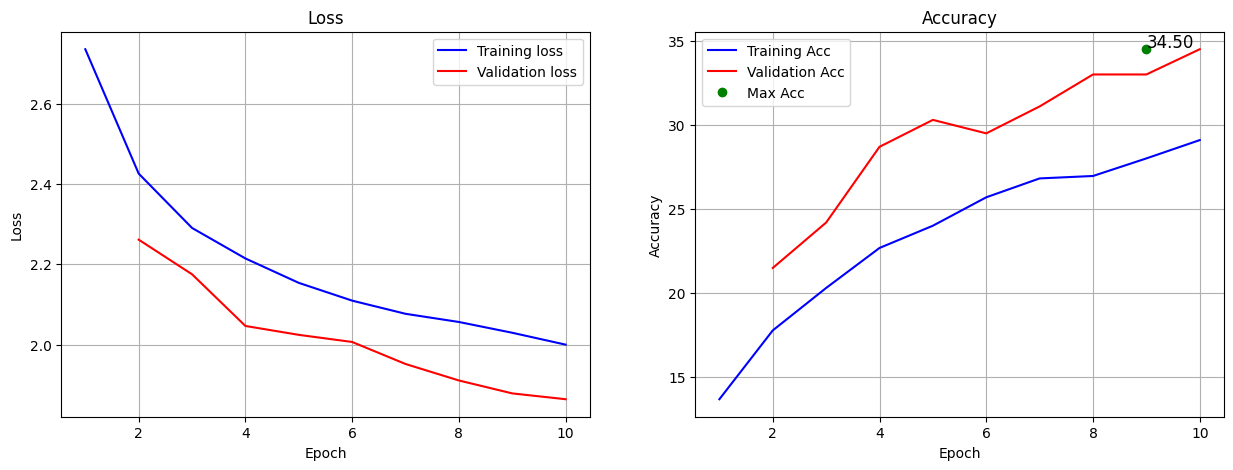

In [16]:
plot_training_history(results_dict, params)

## Test Training With multiple architectures

In [ ]:
# read a txt file containing the decoded nets
import ast
with open('config_files/decoded_nets_1.txt', 'r') as f:
    lines = f.readlines()
    decoded_nets = [ast.literal_eval(line) for line in lines]


In [ ]:
# print the first 5 decoded nets
for i in range(3):
    print(f"Net {i+1}: {decoded_nets[i]}")

In [ ]:
acc_list = {}

In [ ]:
for i, net in enumerate(decoded_nets):
    net_name = f"Net_{i+1}"
    acc = fitness_calculation(id_num=net_name, params=params, fn_dict=fn_dict, net_list=net, debug=True)
    acc_list[net_name] = acc

In [ ]:
from util import create_info_file

In [ ]:
create_info_file(params['experiment_path'], acc_list)

In [ ]:
import pandas as pd
df = pd.DataFrame.from_dict(acc_list, orient='index', columns=['accuracy'])
df = df.sort_values(by=['accuracy'], ascending=False)

In [ ]:
# plot the accuracy of the decoded nets
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(df.index, df['accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Net')
plt.title('Accuracy of the decoded nets')
plt.show()

# Retrain

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
import os
import qnas_config as cfg
from util import check_files
from cnn.input import GenericDataLoader
from cnn.train_detailed import train_and_eval

In [ ]:
phase = 'retrain'
experiment_path = os.path.join("experiments", "exp13_adamw_repeat_2")
config_file = 'config_files/config11.txt'

args = {
    'experiment_path': experiment_path,
    #'config_file': config_file,
    'retrain_folder': 'retrain',
    'data_path': 'cifar10_data',
    'log_level': 'INFO',
    'max_epochs': 300,
    'epochs_to_eval': 10,
    'batch_size': 256,
    'eval_batch_size': 1000,
    'limit_data': False,
    'num_workers': 4,
}

In [ ]:
check_files(args['experiment_path'])
config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict

In [ ]:
config.load_evolved_data(experiment_path=experiment_path)

In [ ]:
params = config.train_spec
params

In [ ]:
evolved_params = config.evolved_params
evolved_params['net']

In [ ]:
data_loader = GenericDataLoader(params=params)

In [ ]:
train_loader, val_loader = data_loader.get_loader(pin_memory_device='cuda:0')
test_loader = data_loader.get_loader(for_train=False, pin_memory_device='cuda:0')

In [ ]:
import pandas as pd

In [ ]:
retrain_multi = []


for i in range(1):
    results = train_and_eval(params=params, fn_dict=fn_dict, net_list=evolved_params['net'], 
                             train_loader=train_loader, val_loader=val_loader, test_loader=test_loader)
    retrain_multi.append(results)
    
    params['experiment_path'] = os.path.join(experiment_path, f"retrain_{i+1}")

results

In [ ]:
# save the results of the retraining into a txt file
with open(os.path.join(experiment_path, 'retrain_results.txt'), 'w') as f:
    for item in retrain_multi:
        f.write("%s\n" % item)

In [ ]:
# results_dict = train_and_eval(params=params, fn_dict=fn_dict, net_list=evolved_params['net'], 
#                               train_loader=train_loader, val_loader=val_loader, test_loader=test_loader)
# results_dict